In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MultiLabelBinarizer, LabelEncoder

In [2]:
# load campaign data set
df = pd.read_csv("../data/nykaa_campaign_data.csv")

# inspecting data set
print(df.head())
print(df.info())
print(df.shape)


   Campaign_ID Campaign_Type        Target_Audience  Duration  \
0  NY-CMP-1000  Social Media       College Students        21   
1  NY-CMP-1001      Paid Ads  Tier 2 City Customers        18   
2  NY-CMP-1002    Influencer                  Youth        23   
3  NY-CMP-1003         Email          Working Women        18   
4  NY-CMP-1004      Paid Ads       College Students        10   

                   Channel_Used  Impressions  Clicks  Leads  Conversions  \
0             WhatsApp, YouTube        57804    6156   3616         2355   
1                       YouTube        91801    3321   1971         1357   
2     WhatsApp, Google, YouTube        15536    2182    952          755   
3  YouTube, Facebook, Instagram        88114    8413   2231          947   
4           Facebook, Instagram        96871    3743   2060         1258   

   Revenue  Acquisition_Cost   ROI Language  Engagement_Score  \
0  1867515            111.03  6.14    Hindi             20.98   
1  1046247            

In [3]:
# Checking for missing values
df.isnull().sum()


# if there were missing values this is an ideal way i would do

# Median handles outliers better than mean.
# numeric_cols = df.select_dtypes(include=np.number).columns
# for col in numeric_cols:
#     df[col] = df[col].fillna(df[col].median())

# categorical_cols = df.select_dtypes(include="object").columns
# for col in categorical_cols:
#     df[col] = df[col].fillna("Unknown")

Campaign_ID         0
Campaign_Type       0
Target_Audience     0
Duration            0
Channel_Used        0
Impressions         0
Clicks              0
Leads               0
Conversions         0
Revenue             0
Acquisition_Cost    0
ROI                 0
Language            0
Engagement_Score    0
Customer_Segment    0
Date                0
dtype: int64

In [4]:
df.duplicated().sum()

# df = df.drop_duplicates()

0

In [5]:
# converting date column, since date themselves ar not useful in ML
# but month, weekday and season can affect campaign perfomance

df["Date"] = pd.to_datetime(
    df["Date"],
    format="%d-%m-%Y"
)

df["Month"] = df["Date"].dt.month
df["Weekday"] = df["Date"].dt.weekday

In [6]:
# creating target variable
median_roi = df["ROI"].median()

df["High_Performance"] = (
    df["ROI"] > median_roi
).astype(int)

In [7]:
# check target balance
# targeting roughly balanced classes is ideal

df["High_Performance"].value_counts()

High_Performance
0    27822
1    27733
Name: count, dtype: int64

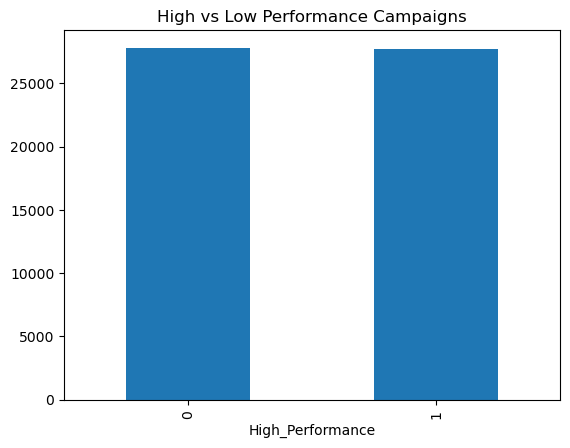

In [8]:
# Visualization targeting

df["High_Performance"].value_counts().plot(kind="bar")

plt.title("High vs Low Performance Campaigns")
plt.show()

In [9]:
# correlation analysis

corr = df.corr(numeric_only=True)

print(corr["High_Performance"].sort_values(ascending=False))

High_Performance    1.000000
Revenue             0.623744
Conversions         0.603886
Leads               0.592030
ROI                 0.584406
Clicks              0.566517
Engagement_Score    0.451055
Impressions         0.422518
Month               0.000099
Weekday            -0.001322
Duration           -0.003069
Acquisition_Cost   -0.475299
Name: High_Performance, dtype: float64


## Do clicks correlate with performance?
Yes, clicks show a solid positive correlation with performance (0.57), meaning campaigns that generate more clicks generally tend to perform better overall.
## Does engagement matter?
Yes, engagement has a meaningful positive correlation with performance (0.45), indicating that more engaged audiences typically contribute to stronger campaign outcomes.
## Does acquisition cost hurt ROI?
Yes, acquisition cost has a clear negative correlation with performance (–0.48), showing that higher costs directly reduce both performance and ROI.


In [10]:
# Visualization of important features

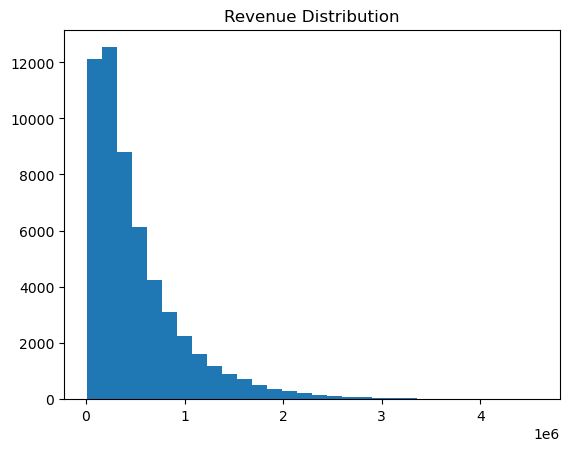

In [11]:
# Revenue distribution
plt.hist(df["Revenue"], bins=30)

plt.title("Revenue Distribution")
plt.show()

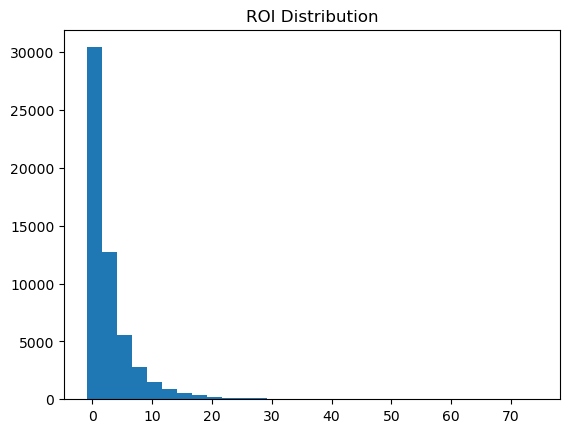

In [12]:
# ROI distribution
plt.hist(df["ROI"], bins=30)

plt.title("ROI Distribution")
plt.show()

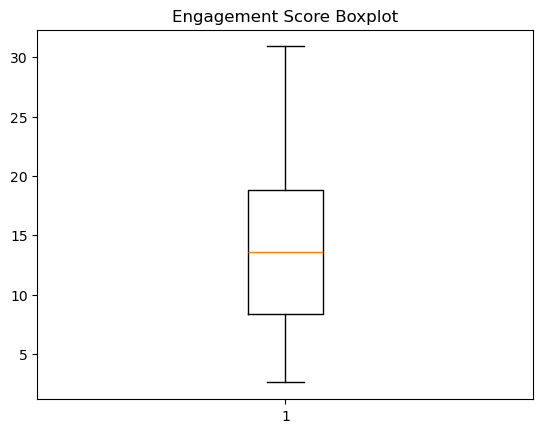

In [13]:
#  Engagement score
plt.boxplot(df["Engagement_Score"])

plt.title("Engagement Score Boxplot")
plt.show()

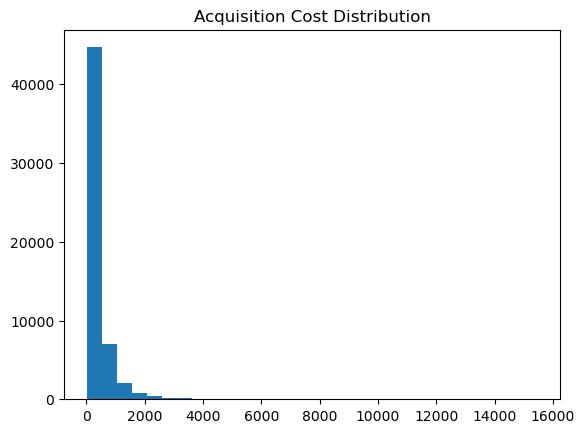

In [14]:
# Acquisition cost
plt.hist(df["Acquisition_Cost"], bins=30)

plt.title("Acquisition Cost Distribution")

plt.show()


In [15]:
numeric_cols = df.select_dtypes(include="number").columns
summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()
    summary.append([col, outlier_count])

outlier_summary = pd.DataFrame(summary, columns=["Column", "Outlier_Count"])
outlier_summary


,Column,Outlier_Count
0,Duration,0
1,Impressions,0
2,Clicks,311
3,Leads,1776
4,Conversions,2333
5,Revenue,3156
6,Acquisition_Cost,4845
7,ROI,4081
8,Engagement_Score,0
9,Month,0


## Why do some numeric columns show thousands of outliers while others show none?

The IQR analysis shows that columns like Duration, Impressions, Engagement Score, Month, Weekday and High_Performance 
have no outliers because their values fall within a tight, consistent range. In contrast, metrics such as 
Clicks, Leads, Conversions, Revenue, Acquisition Cost and ROI naturally vary much more across campaigns, creating long‑tailed distributions. 
The IQR method flags these large variations as outliers even though they are normal for marketing performance data.


In [16]:
# Analyzing Categories
# List of general categorical columns you want to analyze
categorical_cols = [
    "Campaign_Type",
    "Target_Audience",
    "Channel_Used",
    "Language",
    "Customer_Segment"
]

# Numeric performance metrics to compare across categories
performance_metrics = [
    "Impressions",
    "Clicks",
    "Leads",
    "Conversions",
    "Revenue",
    "ROI",
    "Acquisition_Cost",
    "Engagement_Score",
    "High_Performance"
]

# Generate summary tables for each category
category_analysis = {}

for col in categorical_cols:
    category_analysis[col] = df.groupby(col)[performance_metrics].mean().sort_values("High_Performance", ascending=False)

# Display results
for col, table in category_analysis.items():
    print(f"\n===== {col} Performance Summary =====\n")
    print(table)


===== Campaign_Type Performance Summary =====

                Impressions       Clicks        Leads  Conversions  \
Campaign_Type                                                        
Social Media   55310.409843  4725.742127  1896.415872  1043.339482   
SEO            55098.483888  4658.869393  1874.119144  1026.264916   
Influencer     55113.505658  4710.285073  1881.748877  1038.613167   
Paid Ads       55157.233177  4695.875675  1869.272760  1027.849316   
Email          54759.709953  4649.439975  1864.780148  1028.236681   

                     Revenue       ROI  Acquisition_Cost  Engagement_Score  \
Campaign_Type                                                                
Social Media   517530.827785  2.754784        373.263383         13.845957   
SEO            514381.428559  2.709630        378.738830         13.713328   
Influencer     518148.378301  2.699687        375.485535         13.861539   
Paid Ads       517404.550468  2.722275        379.125125         13.751

## Performance Findings by Category

### Campaign Type
Social Media campaigns show the strongest overall performance, with the highest clicks, conversions, and ROI, making them the most effective category. SEO and Influencer campaigns follow closely with similar performance levels, while Paid Ads and Email campaigns lag slightly due to higher acquisition costs and lower conversion efficiency.

### Target Audience
Premium Shoppers stand out as the best‑performing audience, delivering the highest revenue, ROI, and High_Performance scores. College Students also perform strongly, while Youth, Tier 2 City Customers, and Working Women show moderate results with slightly lower conversions and ROI.

### Channel Used
Multi‑channel combinations such as Email + WhatsApp + Facebook and Google + WhatsApp + YouTube deliver the highest conversions, revenue, and ROI. Lower‑performing channel mixes tend to rely heavily on fewer platforms or weaker combinations, resulting in reduced engagement and lower High_Performance scores.

### Language
Performance across languages is very similar, with only slight differences. Bengali and Hindi campaigns show a small edge in ROI and High_Performance scores, while Tamil and English perform slightly lower but remain close in overall effectiveness.

### Customer Segment
Tier 2 City Customers and Premium Shoppers lead in overall performance, showing the highest ROI and High_Performance scores. Working Women also perform well with strong conversions, while Youth and College Students show stable but slightly lower results across key metrics.


In [17]:
# Creating marketing features
# Funnel Efficiency Features
df["CTR"] = df["Clicks"] / df["Impressions"]                     # Click‑Through Rate
df["Lead_Conversion_Rate"] = df["Leads"] / df["Clicks"]          # Leads per Click
df["Final_Conversion_Rate"] = df["Conversions"] / df["Leads"]    # Conversions per Lead
df["Revenue_per_Click"] = df["Revenue"] / df["Clicks"]
df["Revenue_per_Conversion"] = df["Revenue"] / df["Conversions"]

# Cost & ROI Features
df["Cost_per_Lead"] = df["Acquisition_Cost"] / df["Leads"]
df["Cost_per_Conversion"] = df["Acquisition_Cost"] / df["Conversions"]
df["Profit"] = df["Revenue"] - df["Acquisition_Cost"]
df["Profit_Margin"] = df["Profit"] / df["Revenue"]

# Engagement Features
df["Engagement_per_Impression"] = df["Engagement_Score"] / df["Impressions"]
df["Engagement_per_Click"] = df["Engagement_Score"] / df["Clicks"]

# Engagement Tier (High / Medium / Low)
df["Engagement_Tier"] = pd.qcut(df["Engagement_Score"], 3, labels=["Low", "Medium", "High"])

# Channel & Audience Features
df["Channel_Count"] = df["Channel_Used"].apply(lambda x: len(x.split(",")))

# Simple Channel Strength Score (normalize clicks + conversions)
df["Channel_Strength_Score"] = (
    (df["Clicks"] / df["Clicks"].max()) +
    (df["Conversions"] / df["Conversions"].max())
) / 2

# Audience Value Score (ROI + conversions normalized)
df["Audience_Value_Score"] = (
    (df["ROI"] / df["ROI"].max()) +
    (df["Conversions"] / df["Conversions"].max())
) / 2

# Temporal Features
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
df["Quarter"] = df["Date"].dt.quarter
df["Season"] = df["Date"].dt.month % 12 // 3 + 1   # 1=Winter, 2=Spring, 3=Summer, 4=Fall

# Performance Classification
df["Performance_Score"] = (
    df["CTR"] * 0.3 +
    df["Final_Conversion_Rate"] * 0.4 +
    df["ROI"] / df["ROI"].max() * 0.3
)

df["Cost_Efficiency_Score"] = (
    (1 / df["Cost_per_Conversion"]) / (1 / df["Cost_per_Conversion"]).max()
)

# High Performer Flag (top 25%)
df["High_Performer_Flag"] = (df["Performance_Score"] >= df["Performance_Score"].quantile(0.75)).astype(int)

# viewing only engineered features
df[[
    "CTR", "Lead_Conversion_Rate", "Final_Conversion_Rate",
    "Revenue_per_Click", "Revenue_per_Conversion",
    "Cost_per_Lead", "Cost_per_Conversion",
    "Profit", "Profit_Margin",
    "Engagement_per_Impression", "Engagement_per_Click",
    "Engagement_Tier", "Channel_Count",
    "Channel_Strength_Score", "Audience_Value_Score",
    "Quarter", "Season",
    "Performance_Score", "Cost_Efficiency_Score",
    "High_Performer_Flag"
]].head()


,CTR,Lead_Conversion_Rate,Final_Conversion_Rate,Revenue_per_Click,Revenue_per_Conversion,Cost_per_Lead,Cost_per_Conversion,Profit,Profit_Margin,Engagement_per_Impression,Engagement_per_Click,Engagement_Tier,Channel_Count,Channel_Strength_Score,Audience_Value_Score,Quarter,Season,Performance_Score,Cost_Efficiency_Score,High_Performer_Flag
0,0.106498,0.587394,0.651272,303.365010,793.0,0.030705,0.047146,1867403.97,0.999941,0.000363,0.003408,High,2,0.383136,0.217367,2,2,0.317210,0.028805,1
1,0.036176,0.593496,0.688483,315.039747,771.0,0.091745,0.133257,1046066.17,0.999827,0.000079,0.002180,Low,1,0.213164,0.123383,2,2,0.299388,0.010191,0
2,0.140448,0.436297,0.793067,90.309349,261.0,0.095168,0.120000,196964.40,0.999540,0.001611,0.011471,High,3,0.129840,0.069092,1,1,0.366940,0.011317,1
3,0.095479,0.265185,0.424473,44.800428,398.0,0.111641,0.263010,376656.93,0.999339,0.000149,0.001563,Medium,3,0.353743,0.074851,2,3,0.200852,0.005164,0
4,0.038639,0.550361,0.610680,138.470745,412.0,0.110971,0.181717,518067.40,0.999559,0.000075,0.001948,Low,2,0.219952,0.099452,4,1,0.259088,0.007473,0


In [18]:
# handling infinite values
df.replace([np.inf, -np.inf], np.nan, inplace=True)

df = df.dropna()

In [19]:
# Label encoding for single‑value categories
label_cols = [
    "Campaign_Type",
    "Target_Audience",
    "Language",
    "Customer_Segment"
]

for col in label_cols:
    le = LabelEncoder()
    df[col + "_LE"] = le.fit_transform(df[col])

# Multi‑label encoding for Channel_Used
df["Channel_List"] = df["Channel_Used"].apply(lambda x: [c.strip() for c in x.split(",")])

mlb = MultiLabelBinarizer()
channel_df = pd.DataFrame(
    mlb.fit_transform(df["Channel_List"]),
    columns=mlb.classes_,
    index=df.index
)

df = pd.concat([df, channel_df], axis=1)
df.drop(columns=["Channel_List"], inplace=True)


In [21]:
# Remove original categorical columns
drop_cats = [
    "Campaign_Type",
    "Target_Audience",
    "Language",
    "Customer_Segment",
    "Channel_Used"
]

# Remove leakage columns
leakage_cols = [
    "Revenue",
    "ROI",
    "Profit",
    "Profit_Margin",
    "High_Performance",
    "High_Performer_Flag",
    "Performance_Score",
    "Cost_Efficiency_Score",
    "Revenue_per_Click",
    "Revenue_per_Conversion"
]

df_model = df.drop(columns=drop_cats + leakage_cols, errors="ignore")
df_model.head()


,Campaign_ID,Duration,Impressions,Clicks,Leads,Conversions,Acquisition_Cost,Engagement_Score,Date,Month,...,Campaign_Type_LE,Target_Audience_LE,Language_LE,Customer_Segment_LE,Email,Facebook,Google,Instagram,WhatsApp,YouTube
0,NY-CMP-1000,21,57804,6156,3616,2355,111.03,20.98,2025-04-29,4,...,4,0,2,0,0,0,0,0,1,1
1,NY-CMP-1001,18,91801,3321,1971,1357,180.83,7.24,2025-04-06,4,...,2,2,2,0,0,0,0,0,0,1
2,NY-CMP-1002,23,15536,2182,952,755,90.60,25.03,2025-01-14,1,...,1,4,1,0,0,0,1,0,1,1
3,NY-CMP-1003,18,88114,8413,2231,947,249.07,13.15,2025-06-04,6,...,0,3,2,0,0,1,0,1,0,1
4,NY-CMP-1004,10,96871,3743,2060,1258,228.60,7.29,2024-12-29,12,...,2,0,2,2,0,1,0,1,0,0
